
# India VIX + NIFTY Next-Day Gap Prediction — Walk-Forward Research Model

## Objective

Predict whether the **next NIFTY 50 opening gap** will be:

- `GAP_UP`
- `FLAT`
- `GAP_DOWN`

using India VIX as the primary predictor, while allowing NIFTY-derived information to improve directional prediction.

### Key changes from the first version

1. Download a much longer history (default: 10 years).
2. Do **not** assume all historical observations are equally relevant.
3. Compare rolling training windows:
   - 6 months
   - 1 year
   - 2 years
   - 3 years
   - 5 years
4. Use **walk-forward validation** rather than random train/test splitting.
5. Add optional **exponential recency weighting**.
6. Use a **two-stage model**:
   - Stage 1: meaningful GAP vs FLAT
   - Stage 2: GAP_UP vs GAP_DOWN
7. Compare the two-stage model with a direct three-class model.
8. Keep the final test period completely untouched until model/window selection is finished.
9. Evaluate accuracy, balanced accuracy, macro F1, confusion matrices and class-wise performance.
10. Produce a final probability-based prediction for the next trading day.

> Important: this notebook is a research framework. A higher historical score does not guarantee future trading profitability.



# 1. Install and import packages

The notebook uses Yahoo Finance for convenient historical data retrieval.

For production research, cross-check the downloaded data against NSE historical data before relying on the results.


In [1]:

# ============================================================
# 1. INSTALL / IMPORT LIBRARIES
# ============================================================

%pip install -q --upgrade yfinance scikit-learn pandas numpy matplotlib python-dateutil

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from dateutil.relativedelta import relativedelta
from datetime import datetime

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

print("Libraries loaded successfully.")


Note: you may need to restart the kernel to use updated packages.
Libraries loaded successfully.


In [2]:

# ============================================================
# 2. RESEARCH CONFIGURATION
# ============================================================

# ------------------------------------------------------------
# Data history
# ------------------------------------------------------------

HISTORY_YEARS = 10

# ------------------------------------------------------------
# Target definition
# ------------------------------------------------------------

# A gap within +/- this value is classified as FLAT.
FLAT_THRESHOLD_PCT = 0.15

# ------------------------------------------------------------
# Candidate rolling training windows
# ------------------------------------------------------------

TRAINING_WINDOWS_MONTHS = [6, 12, 24, 36, 60]

# ------------------------------------------------------------
# Walk-forward validation
# ------------------------------------------------------------

VALIDATION_MONTHS = 2

# Minimum observations required for a training window.
MIN_TRAIN_OBS = 80

# ------------------------------------------------------------
# Recency weighting
# ------------------------------------------------------------

USE_RECENCY_WEIGHTING = True

# Half-life in months.
# After this many months, an observation receives approximately
# half the weight of a current observation.
RECENCY_HALF_LIFE_MONTHS = 12

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------

RANDOM_STATE = 42

print("Configuration loaded.")
print(f"History: {HISTORY_YEARS} years")
print(f"Flat threshold: ±{FLAT_THRESHOLD_PCT}%")
print(f"Candidate windows: {TRAINING_WINDOWS_MONTHS} months")
print(f"Recency weighting: {USE_RECENCY_WEIGHTING}")


Configuration loaded.
History: 10 years
Flat threshold: ±0.15%
Candidate windows: [6, 12, 24, 36, 60] months
Recency weighting: True



# 3. Download India VIX and NIFTY 50 data

We download:

- `^INDIAVIX` — India VIX
- `^NSEI` — NIFTY 50

The target is:

\[
Gap_{t+1} =
\left(
\frac{NIFTY\ Open_{t+1}}
{NIFTY\ Close_t}
-1
\right)\times100
\]

Only information available on day `t` is allowed into the feature set.


In [3]:

# ============================================================
# 3. DOWNLOAD DATA
# ============================================================

today = pd.Timestamp.today().normalize()

# Add a buffer before the requested history because rolling
# features need historical observations.
download_start = (
    today
    - relativedelta(years=HISTORY_YEARS)
    - relativedelta(months=2)
)

download_end = today + pd.Timedelta(days=1)

print("Downloading:")
print("Start:", download_start.date())
print("End:  ", today.date())

vix_raw = yf.download(
    "^INDIAVIX",
    start=download_start.strftime("%Y-%m-%d"),
    end=download_end.strftime("%Y-%m-%d"),
    auto_adjust=False,
    progress=False
)

nifty_raw = yf.download(
    "^NSEI",
    start=download_start.strftime("%Y-%m-%d"),
    end=download_end.strftime("%Y-%m-%d"),
    auto_adjust=False,
    progress=False
)

if vix_raw.empty:
    raise ValueError("India VIX download returned no data.")

if nifty_raw.empty:
    raise ValueError("NIFTY 50 download returned no data.")

print("India VIX rows:", len(vix_raw))
print("NIFTY rows:", len(nifty_raw))


Downloading:
Start: 2016-08-03
End:   2026-10-03
India VIX rows: 2491
NIFTY rows: 2505


In [4]:

# ============================================================
# 4. CLEAN YFINANCE DATA
# ============================================================

def clean_yfinance(df):
    df = df.copy()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df.index = pd.to_datetime(df.index).tz_localize(None)
    df = df.sort_index()

    required = ["Open", "High", "Low", "Close"]
    missing = [c for c in required if c not in df.columns]

    if missing:
        raise ValueError(f"Missing columns: {missing}")

    return df

vix = clean_yfinance(vix_raw)
nifty = clean_yfinance(nifty_raw)

print("VIX:")
display(vix.tail())

print("NIFTY:")
display(nifty.tail())


VIX:


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-09-25,12.16,12.16,12.84,11.77,12.69,0
2026-09-28,13.64,13.64,14.15,12.16,12.16,0
2026-09-29,13.41,13.41,14.77,13.21,13.64,0
2026-09-30,13.49,13.49,13.86,12.77,13.41,0
2026-10-01,14.46,14.46,15.69,13.49,13.49,0


NIFTY:


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-09-25,23140.500000,23140.500000,23162.699219,23020.949219,23035.000000,242700
2026-09-28,22780.250000,22780.250000,23080.250000,22762.199219,23064.900391,261500
2026-09-29,22716.199219,22716.199219,22753.250000,22569.650391,22732.449219,603200
2026-09-30,22620.449219,22620.449219,22809.349609,22595.199219,22665.000000,379000
2026-10-01,22421.949219,22421.949219,22610.599609,22217.300781,22543.699219,463600



# 5. Construct the research dataset

We intentionally distinguish:

### VIX features
These describe the level, momentum, acceleration and volatility of India VIX.

### NIFTY features
These describe information that was already known by the NIFTY close on day `t`.

### Target
The next day's NIFTY opening gap.

No next-day information is included in the feature matrix.


In [7]:
# ============================================================
# 5. MERGE DATA + CREATE TARGETS
# ============================================================

df = vix[["Open", "High", "Low", "Close"]].rename(
    columns={
        "Open": "VIX_Open",
        "High": "VIX_High",
        "Low": "VIX_Low",
        "Close": "VIX_Close"
    }
).join(
    nifty[["Open", "High", "Low", "Close"]].rename(
        columns={
            "Open": "NIFTY_Open",
            "High": "NIFTY_High",
            "Low": "NIFTY_Low",
            "Close": "NIFTY_Close"
        }
    ),
    how="inner"
)

# Make sure the index is sorted chronologically
df = df.sort_index()

# ------------------------------------------------------------
# Target: next day's NIFTY opening gap
# ------------------------------------------------------------

df["Next_NIFTY_Open"] = df["NIFTY_Open"].shift(-1)

df["Gap_Pct"] = (
    (df["Next_NIFTY_Open"] / df["NIFTY_Close"]) - 1
) * 100

# ------------------------------------------------------------
# Three-class target
# ------------------------------------------------------------

# Use pandas Series instead of np.select to avoid NumPy
# string/float dtype-promotion problems.

df["Target_3Class"] = pd.Series(
    "FLAT",
    index=df.index,
    dtype="string"
)

df.loc[
    df["Gap_Pct"] > FLAT_THRESHOLD_PCT,
    "Target_3Class"
] = "GAP_UP"

df.loc[
    df["Gap_Pct"] < -FLAT_THRESHOLD_PCT,
    "Target_3Class"
] = "GAP_DOWN"

# ------------------------------------------------------------
# Stage 1 target: meaningful GAP vs FLAT
# ------------------------------------------------------------

df["Target_Gap"] = (
    df["Gap_Pct"].abs() > FLAT_THRESHOLD_PCT
).astype(int)

# ------------------------------------------------------------
# Stage 2 target: UP vs DOWN
# Only meaningful gaps receive a direction.
# FLAT observations remain missing for Stage 2.
# ------------------------------------------------------------

df["Target_Direction"] = pd.Series(
    pd.NA,
    index=df.index,
    dtype="string"
)

df.loc[
    df["Gap_Pct"] > FLAT_THRESHOLD_PCT,
    "Target_Direction"
] = "GAP_UP"

df.loc[
    df["Gap_Pct"] < -FLAT_THRESHOLD_PCT,
    "Target_Direction"
] = "GAP_DOWN"

# ------------------------------------------------------------
# Check the results
# ------------------------------------------------------------

print("Dataset shape:", df.shape)

print("\nThree-class target:")
display(
    df["Target_3Class"]
    .value_counts(dropna=False)
    .rename("Count")
    .to_frame()
)

print("\nStage 1 target:")
display(
    df["Target_Gap"]
    .value_counts(dropna=False)
    .rename("Count")
    .to_frame()
)

print("\nStage 2 target:")
display(
    df["Target_Direction"]
    .value_counts(dropna=False)
    .rename("Count")
    .to_frame()
)

display(df.tail())

Dataset shape: (2488, 13)

Three-class target:


,Count
Target_3Class,
GAP_UP,1227
FLAT,724
GAP_DOWN,537



Stage 1 target:


,Count
Target_Gap,
1,1764
0,724



Stage 2 target:


,Count
Target_Direction,
GAP_UP,1227
<NA>,724
GAP_DOWN,537


Price,VIX_Open,VIX_High,VIX_Low,VIX_Close,NIFTY_Open,NIFTY_High,NIFTY_Low,NIFTY_Close,Next_NIFTY_Open,Gap_Pct,Target_3Class,Target_Gap,Target_Direction
Date,,,,,,,,,,,,,
2026-09-25,12.69,12.84,11.77,12.16,23035.000000,23162.699219,23020.949219,23140.500000,23064.900391,-0.326698,GAP_DOWN,1,GAP_DOWN
2026-09-28,12.16,14.15,12.16,13.64,23064.900391,23080.250000,22762.199219,22780.250000,22732.449219,-0.209834,GAP_DOWN,1,GAP_DOWN
2026-09-29,13.64,14.77,13.21,13.41,22732.449219,22753.250000,22569.650391,22716.199219,22665.000000,-0.225386,GAP_DOWN,1,GAP_DOWN
2026-09-30,13.41,13.86,12.77,13.49,22665.000000,22809.349609,22595.199219,22620.449219,22543.699219,-0.339295,GAP_DOWN,1,GAP_DOWN
2026-10-01,13.49,15.69,13.49,14.46,22543.699219,22610.599609,22217.300781,22421.949219,NaN,NaN,FLAT,0,<NA>


In [8]:

# ============================================================
# 6. ENGINEER INDIA VIX FEATURES
# ============================================================

# Basic VIX features
df["VIX_Return_1D"] = df["VIX_Close"].pct_change() * 100

df["VIX_Range_Pct"] = (
    (df["VIX_High"] - df["VIX_Low"])
    / df["VIX_Close"]
) * 100

vix_range = (
    df["VIX_High"] - df["VIX_Low"]
).replace(0, np.nan)

df["VIX_Close_Position"] = (
    (df["VIX_Close"] - df["VIX_Low"])
    / vix_range
)

# Momentum
for n in [2, 3, 5, 10, 20, 60]:
    df[f"VIX_Return_{n}D"] = (
        df["VIX_Close"].pct_change(n) * 100
    )

# Rolling statistics
for n in [5, 10, 20, 60]:
    df[f"VIX_MA_{n}D"] = (
        df["VIX_Close"].rolling(n).mean()
    )

    df[f"VIX_STD_{n}D"] = (
        df["VIX_Return_1D"].rolling(n).std()
    )

# Distance from moving averages
for n in [5, 10, 20, 60]:
    df[f"VIX_Distance_MA{n}_Pct"] = (
        df["VIX_Close"] / df[f"VIX_MA_{n}D"] - 1
    ) * 100

# VIX acceleration
df["VIX_Acceleration_1D"] = (
    df["VIX_Return_1D"].diff()
)

df["VIX_Acceleration_5D"] = (
    df["VIX_Return_5D"].diff()
)

# VIX rolling percentile
def rolling_percentile_last(x):
    if len(x) == 0:
        return np.nan
    return pd.Series(x).rank(pct=True).iloc[-1]

df["VIX_Percentile_60D"] = (
    df["VIX_Close"]
    .rolling(60)
    .apply(rolling_percentile_last, raw=False)
)

print("VIX feature engineering completed.")


VIX feature engineering completed.


In [9]:

# ============================================================
# 7. ENGINEER NIFTY FEATURES
# ============================================================

# Returns known by the current day's close
for n in [1, 2, 3, 5, 10, 20, 60]:
    df[f"NIFTY_Return_{n}D"] = (
        df["NIFTY_Close"].pct_change(n) * 100
    )

# Intraday return
df["NIFTY_Intraday_Return"] = (
    df["NIFTY_Close"] / df["NIFTY_Open"] - 1
) * 100

# Intraday range
df["NIFTY_Range_Pct"] = (
    (df["NIFTY_High"] - df["NIFTY_Low"])
    / df["NIFTY_Close"]
) * 100

# Historical rolling volatility
for n in [5, 10, 20, 60]:
    df[f"NIFTY_Volatility_{n}D"] = (
        df["NIFTY_Return_1D"]
        .rolling(n)
        .std()
    )

# Moving averages
for n in [5, 10, 20, 50, 100]:
    df[f"NIFTY_MA_{n}D"] = (
        df["NIFTY_Close"].rolling(n).mean()
    )

    df[f"NIFTY_Distance_MA{n}_Pct"] = (
        df["NIFTY_Close"] /
        df[f"NIFTY_MA_{n}D"] - 1
    ) * 100

# Drawdown from rolling highs
for n in [20, 60, 120]:
    rolling_high = df["NIFTY_Close"].rolling(n).max()

    df[f"NIFTY_Drawdown_{n}D"] = (
        df["NIFTY_Close"] / rolling_high - 1
    ) * 100

# Previous observed opening gaps
df["Previous_Gap_Pct"] = (
    df["NIFTY_Open"] /
    df["NIFTY_Close"].shift(1) - 1
) * 100

df["Previous_Gap_3D_Mean"] = (
    df["Previous_Gap_Pct"].rolling(3).mean()
)

df["Previous_Gap_5D_Mean"] = (
    df["Previous_Gap_Pct"].rolling(5).mean()
)

df["Previous_Gap_10D_Mean"] = (
    df["Previous_Gap_Pct"].rolling(10).mean()
)

print("NIFTY feature engineering completed.")


NIFTY feature engineering completed.



# 8. Add calendar effects

These are deterministic variables known before the next opening.

The model may discover that the probability of a particular type of gap differs across weekdays or month-end periods.

These variables should be treated as exploratory features rather than assumed predictors.


In [10]:

# ============================================================
# 8. CALENDAR FEATURES
# ============================================================

df["DayOfWeek"] = df.index.dayofweek

df["Month"] = df.index.month

df["DayOfMonth"] = df.index.day

df["IsMonthEnd"] = df.index.is_month_end.astype(int)

df["IsMonthStart"] = df.index.is_month_start.astype(int)

# Cyclical encoding
df["DayOfWeek_Sin"] = np.sin(
    2 * np.pi * df["DayOfWeek"] / 5
)

df["DayOfWeek_Cos"] = np.cos(
    2 * np.pi * df["DayOfWeek"] / 5
)

print("Calendar features added.")


Calendar features added.


In [11]:

# ============================================================
# 9. SELECT FEATURE GROUPS
# ============================================================

VIX_FEATURES = [
    c for c in df.columns
    if c.startswith("VIX_")
]

NIFTY_FEATURES = [
    c for c in df.columns
    if c.startswith("NIFTY_")
    and c not in [
        "NIFTY_Open",
        "NIFTY_High",
        "NIFTY_Low",
        "NIFTY_Close"
    ]
]

GAP_FEATURES = [
    "Previous_Gap_Pct",
    "Previous_Gap_3D_Mean",
    "Previous_Gap_5D_Mean",
    "Previous_Gap_10D_Mean"
]

CALENDAR_FEATURES = [
    "DayOfWeek",
    "Month",
    "DayOfMonth",
    "IsMonthEnd",
    "IsMonthStart",
    "DayOfWeek_Sin",
    "DayOfWeek_Cos"
]

ALL_FEATURES = (
    VIX_FEATURES
    + NIFTY_FEATURES
    + GAP_FEATURES
    + CALENDAR_FEATURES
)

# Remove duplicate feature names while preserving order.
ALL_FEATURES = list(dict.fromkeys(ALL_FEATURES))

print("Number of VIX features:", len(VIX_FEATURES))
print("Number of NIFTY features:", len(NIFTY_FEATURES))
print("Number of gap features:", len(GAP_FEATURES))
print("Number of calendar features:", len(CALENDAR_FEATURES))
print("Total features:", len(ALL_FEATURES))


Number of VIX features: 28
Number of NIFTY features: 26
Number of gap features: 4
Number of calendar features: 7
Total features: 65


In [12]:

# ============================================================
# 10. FINAL MODELING DATASET
# ============================================================

# Restrict to the requested history.
history_start = today - relativedelta(years=HISTORY_YEARS)

model_df = df[
    df.index >= history_start
].copy()

# Remove rows with missing features/target.
model_df = model_df.dropna(
    subset=ALL_FEATURES + ["Gap_Pct", "Target_3Class", "Target_Gap"]
).copy()

print("Modeling observations:", len(model_df))

print("\nThree-class target distribution:")
display(
    model_df["Target_3Class"]
    .value_counts()
    .rename("Count")
    .to_frame()
)

print("\nThree-class target percentage:")
display(
    (
        model_df["Target_3Class"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename("Percentage")
        .to_frame()
    )
)


Modeling observations: 2368

Three-class target distribution:


,Count
Target_3Class,
GAP_UP,1165
FLAT,685
GAP_DOWN,518



Three-class target percentage:


,Percentage
Target_3Class,
GAP_UP,49.2
FLAT,28.93
GAP_DOWN,21.88



# 11. Hold out a final untouched test period

The final period is **not used to choose the training window or model**.

This is critical.

We first use older data for walk-forward model selection. Only after deciding the appropriate window do we evaluate once on the final test period.

Default:

- **Final 3 months = untouched test set**
- Everything before that = model-selection period


In [13]:

# ============================================================
# 11. FINAL HOLDOUT
# ============================================================

FINAL_TEST_MONTHS = 3

final_test_start = (
    model_df.index.max()
    - relativedelta(months=FINAL_TEST_MONTHS)
)

development_df = model_df[
    model_df.index < final_test_start
].copy()

final_test = model_df[
    model_df.index >= final_test_start
].copy()

print("Development period:")
print(
    development_df.index.min().date(),
    "to",
    development_df.index.max().date()
)

print("\nFinal untouched test:")
print(
    final_test.index.min().date(),
    "to",
    final_test.index.max().date()
)

print("\nDevelopment observations:", len(development_df))
print("Final test observations:", len(final_test))


Development period:
2017-01-30 to 2026-06-29

Final untouched test:
2026-06-30 to 2026-09-30

Development observations: 2302
Final test observations: 66



# 12. Recency weighting

Older data can still be useful, but we do not necessarily want a 2017 observation to count exactly the same as a 2026 observation.

We therefore support exponential decay:

\[
w = 2^{-Age/H}
\]

where:

- `Age` = age of observation in months
- `H` = half-life

With a 12-month half-life:

- current observation → 1.00
- 12 months old → 0.50
- 24 months old → 0.25
- 36 months old → 0.125

The half-life is itself a research parameter and should ideally be validated.


In [14]:

# ============================================================
# 12. RECENCY WEIGHT FUNCTION
# ============================================================

def calculate_recency_weights(index, reference_date, half_life_months=12):
    age_days = (
        pd.Timestamp(reference_date) -
        pd.to_datetime(index)
    ).days

    age_months = np.maximum(age_days / 30.4375, 0)

    weights = 2 ** (
        -age_months / half_life_months
    )

    return weights


def get_sample_weights(index, reference_date):
    if not USE_RECENCY_WEIGHTING:
        return np.ones(len(index))

    return calculate_recency_weights(
        index=index,
        reference_date=reference_date,
        half_life_months=RECENCY_HALF_LIFE_MONTHS
    )

print("Recency weighting function ready.")


Recency weighting function ready.



# 13. Model definitions

We compare:

### Model A — Logistic Regression
A simple linear baseline.

### Model B — HistGradientBoosting
A nonlinear tree-based model capable of capturing interactions between VIX and NIFTY features.

The direct three-class model predicts:

`GAP_DOWN / FLAT / GAP_UP`

The two-stage system predicts:

**Stage 1**

`FLAT / GAP`

**Stage 2**

`GAP_DOWN / GAP_UP`

The two-stage approach is motivated by the fact that India VIX measures expected volatility more directly than direction.


In [15]:

# ============================================================
# 13. MODEL FACTORIES
# ============================================================

def make_logistic_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ])


def make_hgb_model():
    return HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=RANDOM_STATE
    )


MODEL_FACTORIES = {
    "Logistic": make_logistic_model,
    "HistGradientBoosting": make_hgb_model
}

print("Models ready:", list(MODEL_FACTORIES.keys()))


Models ready: ['Logistic', 'HistGradientBoosting']



# 14. Walk-forward validation

For each historical validation date:

1. Use only observations before that date.
2. Select a rolling training window.
3. Fit the model.
4. Predict the following validation period.
5. Move forward.
6. Repeat.

This mimics how the model would actually have been used in the market.

We will compare different training windows rather than assuming one is optimal.


In [16]:

# ============================================================
# 14. WALK-FORWARD VALIDATION FUNCTION
# ============================================================

def walk_forward_direct_classifier(
    data,
    features,
    target_col,
    window_months,
    validation_months=2,
    model_factory=make_hgb_model
):
    """
    Walk-forward validation for the direct 3-class classifier.
    """

    data = data.sort_index().copy()

    min_date = data.index.min()
    max_date = data.index.max()

    predictions = []

    validation_start = (
        min_date + relativedelta(months=window_months)
    )

    while validation_start < max_date:

        validation_end = min(
            validation_start + relativedelta(months=validation_months),
            max_date
        )

        train_start = (
            validation_start -
            relativedelta(months=window_months)
        )

        train_data = data[
            (data.index >= train_start) &
            (data.index < validation_start)
        ].copy()

        validation_data = data[
            (data.index >= validation_start) &
            (data.index < validation_end)
        ].copy()

        if (
            len(train_data) < MIN_TRAIN_OBS
            or validation_data.empty
        ):
            validation_start = validation_end
            continue

        X_train = train_data[features]
        y_train = train_data[target_col]

        X_val = validation_data[features]

        model = model_factory()

        sample_weight = get_sample_weights(
            train_data.index,
            validation_start
        )

        # HistGradientBoosting accepts sample_weight.
        # LogisticRegression inside a pipeline also accepts
        # model__sample_weight.
        if isinstance(model, Pipeline):
            model.fit(
                X_train,
                y_train,
                model__sample_weight=sample_weight
            )
        else:
            model.fit(
                X_train,
                y_train,
                sample_weight=sample_weight
            )

        pred = model.predict(X_val)

        temp = validation_data[
            ["Gap_Pct", target_col]
        ].copy()

        temp["Prediction"] = pred
        temp["Validation_Date"] = validation_start

        predictions.append(temp)

        validation_start = validation_end

    if not predictions:
        return pd.DataFrame()

    return pd.concat(predictions).sort_index()


def evaluate_predictions(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),
        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro"
        )
    }

print("Walk-forward function ready.")


Walk-forward function ready.



# 15. Compare training windows and models

This is the key experiment.

We ask:

> Does a 6-month model actually outperform a 1-, 2-, 3-, or 5-year model when evaluated repeatedly on future data?

The answer should determine our training window rather than intuition alone.


In [18]:

# ============================================================
# 15. DIRECT 3-CLASS WALK-FORWARD EXPERIMENT
# ============================================================

direct_results = []
direct_predictions = {}

for model_name, factory in MODEL_FACTORIES.items():

    for window in TRAINING_WINDOWS_MONTHS:

        print(
            f"Running: {model_name} | "
            f"{window}-month window"
        )

        pred_df = walk_forward_direct_classifier(
            data=development_df,
            features=ALL_FEATURES,
            target_col="Target_3Class",
            window_months=window,
            validation_months=VALIDATION_MONTHS,
            model_factory=factory
        )

        if pred_df.empty:
            continue

        metrics = evaluate_predictions(
            pred_df["Target_3Class"],
            pred_df["Prediction"]
        )

        direct_results.append({
            "Model": model_name,
            "Training_Window_Months": window,
            "Observations": len(pred_df),
            **metrics
        })

        direct_predictions[
            (model_name, window)
        ] = pred_df

direct_results_df = pd.DataFrame(direct_results)

display(
    direct_results_df.sort_values(
        "Balanced_Accuracy",
        ascending=False
    )
)


Running: Logistic | 6-month window
Running: Logistic | 12-month window
Running: Logistic | 24-month window
Running: Logistic | 36-month window
Running: Logistic | 60-month window
Running: HistGradientBoosting | 6-month window
Running: HistGradientBoosting | 12-month window
Running: HistGradientBoosting | 24-month window
Running: HistGradientBoosting | 36-month window
Running: HistGradientBoosting | 60-month window


,Model,Training_Window_Months,Observations,Accuracy,Balanced_Accuracy,Macro_F1
9,HistGradientBoosting,60,1080,0.437037,0.390835,0.382473
4,Logistic,60,1080,0.375000,0.386426,0.371809
8,HistGradientBoosting,36,1566,0.453384,0.383398,0.376938
3,Logistic,36,1566,0.369732,0.377948,0.364403
6,HistGradientBoosting,12,2053,0.444715,0.370177,0.363655
7,HistGradientBoosting,24,1807,0.448257,0.369576,0.360139
5,HistGradientBoosting,6,2177,0.434084,0.362770,0.358898
1,Logistic,12,2053,0.360448,0.348027,0.343646
2,Logistic,24,1807,0.343664,0.346868,0.336281
0,Logistic,6,2177,0.358751,0.335565,0.333414



# 16. Two-stage classifier

The two-stage model is designed around the economic distinction:

### Stage 1
Is tomorrow's opening move likely to be meaningful?

\[
|Gap| > threshold
\]

### Stage 2
If a meaningful gap occurs, which direction?

\[
Gap > threshold
\]

vs.

\[
Gap < -threshold
\]

The final output is reconstructed as:

- Stage 1 says FLAT → `FLAT`
- Stage 1 says GAP + Stage 2 says UP → `GAP_UP`
- Stage 1 says GAP + Stage 2 says DOWN → `GAP_DOWN`


In [19]:

# ============================================================
# 16. TWO-STAGE WALK-FORWARD VALIDATION
# ============================================================

def walk_forward_two_stage(
    data,
    features,
    window_months,
    validation_months=2,
    model_factory=make_hgb_model
):
    data = data.sort_index().copy()

    min_date = data.index.min()
    max_date = data.index.max()

    predictions = []

    validation_start = (
        min_date + relativedelta(months=window_months)
    )

    while validation_start < max_date:

        validation_end = min(
            validation_start + relativedelta(months=validation_months),
            max_date
        )

        train_start = (
            validation_start -
            relativedelta(months=window_months)
        )

        train_data = data[
            (data.index >= train_start) &
            (data.index < validation_start)
        ].copy()

        validation_data = data[
            (data.index >= validation_start) &
            (data.index < validation_end)
        ].copy()

        if (
            len(train_data) < MIN_TRAIN_OBS
            or validation_data.empty
        ):
            validation_start = validation_end
            continue

        X_train = train_data[features]
        X_val = validation_data[features]

        # ----------------------------------------------------
        # Stage 1: GAP vs FLAT
        # ----------------------------------------------------

        stage1_model = model_factory()

        y1_train = train_data["Target_Gap"]

        sample_weight = get_sample_weights(
            train_data.index,
            validation_start
        )

        if isinstance(stage1_model, Pipeline):
            stage1_model.fit(
                X_train,
                y1_train,
                model__sample_weight=sample_weight
            )
        else:
            stage1_model.fit(
                X_train,
                y1_train,
                sample_weight=sample_weight
            )

        stage1_pred = stage1_model.predict(X_val)

        # ----------------------------------------------------
        # Stage 2: UP vs DOWN
        # ----------------------------------------------------

        gap_train = train_data[
            train_data["Target_Gap"] == 1
        ].copy()

        if (
            len(gap_train) < 30
            or gap_train["Target_Direction"].nunique() < 2
        ):
            validation_start = validation_end
            continue

        stage2_model = model_factory()

        X2_train = gap_train[features]
        y2_train = gap_train["Target_Direction"]

        stage2_weight = get_sample_weights(
            gap_train.index,
            validation_start
        )

        if isinstance(stage2_model, Pipeline):
            stage2_model.fit(
                X2_train,
                y2_train,
                model__sample_weight=stage2_weight
            )
        else:
            stage2_model.fit(
                X2_train,
                y2_train,
                sample_weight=stage2_weight
            )

        stage2_pred = stage2_model.predict(X_val)

        # ----------------------------------------------------
        # Combine the two stages
        # ----------------------------------------------------

        final_pred = np.where(
            stage1_pred == 0,
            "FLAT",
            stage2_pred
        )

        temp = validation_data[
            ["Gap_Pct", "Target_3Class"]
        ].copy()

        temp["Prediction"] = final_pred
        temp["Stage1_Prediction"] = stage1_pred
        temp["Stage2_Prediction"] = stage2_pred

        predictions.append(temp)

        validation_start = validation_end

    if not predictions:
        return pd.DataFrame()

    return pd.concat(predictions).sort_index()


two_stage_results = []
two_stage_predictions = {}

for model_name, factory in MODEL_FACTORIES.items():

    for window in TRAINING_WINDOWS_MONTHS:

        print(
            f"Two-stage: {model_name} | "
            f"{window}-month window"
        )

        pred_df = walk_forward_two_stage(
            data=development_df,
            features=ALL_FEATURES,
            window_months=window,
            validation_months=VALIDATION_MONTHS,
            model_factory=factory
        )

        if pred_df.empty:
            continue

        metrics = evaluate_predictions(
            pred_df["Target_3Class"],
            pred_df["Prediction"]
        )

        two_stage_results.append({
            "Model": model_name,
            "Training_Window_Months": window,
            "Observations": len(pred_df),
            **metrics
        })

        two_stage_predictions[
            (model_name, window)
        ] = pred_df

two_stage_results_df = pd.DataFrame(two_stage_results)

display(
    two_stage_results_df.sort_values(
        "Balanced_Accuracy",
        ascending=False
    )
)


Two-stage: Logistic | 6-month window
Two-stage: Logistic | 12-month window
Two-stage: Logistic | 24-month window
Two-stage: Logistic | 36-month window
Two-stage: Logistic | 60-month window
Two-stage: HistGradientBoosting | 6-month window
Two-stage: HistGradientBoosting | 12-month window
Two-stage: HistGradientBoosting | 24-month window
Two-stage: HistGradientBoosting | 36-month window
Two-stage: HistGradientBoosting | 60-month window


,Model,Training_Window_Months,Observations,Accuracy,Balanced_Accuracy,Macro_F1
4,Logistic,60,1080,0.394444,0.406020,0.382988
3,Logistic,36,1566,0.380587,0.393815,0.368678
9,HistGradientBoosting,60,1080,0.443519,0.383656,0.363833
8,HistGradientBoosting,36,1566,0.473180,0.376287,0.355374
7,HistGradientBoosting,24,1807,0.470393,0.372301,0.354488
1,Logistic,12,2053,0.368242,0.365065,0.353041
6,HistGradientBoosting,12,2053,0.448612,0.364454,0.353252
2,Logistic,24,1807,0.346984,0.356101,0.335490
5,HistGradientBoosting,6,2177,0.438677,0.355189,0.345729
0,Logistic,6,2177,0.369775,0.353672,0.347929



# 17. Compare direct vs two-stage approaches

Do not choose the winner from raw accuracy alone.

For a three-class problem, **balanced accuracy and macro F1** are particularly useful because they prevent a dominant class from hiding poor performance on another class.


In [20]:

# ============================================================
# 17. COMBINED MODEL COMPARISON
# ============================================================

direct_summary = direct_results_df.copy()
direct_summary["Architecture"] = "Direct 3-Class"

two_stage_summary = two_stage_results_df.copy()
two_stage_summary["Architecture"] = "Two-Stage"

comparison = pd.concat(
    [direct_summary, two_stage_summary],
    ignore_index=True
)

comparison = comparison[
    [
        "Architecture",
        "Model",
        "Training_Window_Months",
        "Observations",
        "Accuracy",
        "Balanced_Accuracy",
        "Macro_F1"
    ]
].sort_values(
    "Balanced_Accuracy",
    ascending=False
)

display(comparison)


,Architecture,Model,Training_Window_Months,Observations,Accuracy,Balanced_Accuracy,Macro_F1
14,Two-Stage,Logistic,60,1080,0.394444,0.406020,0.382988
13,Two-Stage,Logistic,36,1566,0.380587,0.393815,0.368678
9,Direct 3-Class,HistGradientBoosting,60,1080,0.437037,0.390835,0.382473
4,Direct 3-Class,Logistic,60,1080,0.375000,0.386426,0.371809
19,Two-Stage,HistGradientBoosting,60,1080,0.443519,0.383656,0.363833
8,Direct 3-Class,HistGradientBoosting,36,1566,0.453384,0.383398,0.376938
3,Direct 3-Class,Logistic,36,1566,0.369732,0.377948,0.364403
18,Two-Stage,HistGradientBoosting,36,1566,0.473180,0.376287,0.355374
17,Two-Stage,HistGradientBoosting,24,1807,0.470393,0.372301,0.354488
6,Direct 3-Class,HistGradientBoosting,12,2053,0.444715,0.370177,0.363655



# 18. Select the research configuration

The selection rule below uses **walk-forward balanced accuracy**.

This is deliberately based only on the development period.

The final test period remains untouched.

You can change the selection metric if your research objective is different.


In [21]:

# ============================================================
# 18. SELECT BEST CONFIGURATION
# ============================================================

best_row = comparison.iloc[0]

best_architecture = best_row["Architecture"]
best_model_name = best_row["Model"]
best_window = int(best_row["Training_Window_Months"])

print("SELECTED CONFIGURATION")
print("----------------------")
print("Architecture:", best_architecture)
print("Model:", best_model_name)
print("Training window:", best_window, "months")
print("Walk-forward balanced accuracy:",
      f"{best_row['Balanced_Accuracy']:.2%}")
print("Walk-forward macro F1:",
      f"{best_row['Macro_F1']:.2%}")


SELECTED CONFIGURATION
----------------------
Architecture: Two-Stage
Model: Logistic
Training window: 60 months
Walk-forward balanced accuracy: 40.60%
Walk-forward macro F1: 38.30%



# 19. Examine walk-forward performance through time

A single aggregate score can hide regime dependence.

We therefore calculate performance by validation period.

If performance is strong only during one historical regime and weak elsewhere, that is important information even if the overall average looks attractive.


In [22]:

# ============================================================
# 19. PERFORMANCE BY PERIOD
# ============================================================

if best_architecture == "Direct 3-Class":
    selected_predictions = direct_predictions[
        (best_model_name, best_window)
    ].copy()
else:
    selected_predictions = two_stage_predictions[
        (best_model_name, best_window)
    ].copy()

selected_predictions["Year"] = (
    selected_predictions.index.year
)

period_performance = []

for year, group in selected_predictions.groupby("Year"):

    period_performance.append({
        "Year": year,
        "Observations": len(group),
        "Accuracy": accuracy_score(
            group["Target_3Class"],
            group["Prediction"]
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            group["Target_3Class"],
            group["Prediction"]
        ),
        "Macro_F1": f1_score(
            group["Target_3Class"],
            group["Prediction"],
            average="macro"
        )
    })

period_performance_df = pd.DataFrame(
    period_performance
)

display(period_performance_df)


,Year,Observations,Accuracy,Balanced_Accuracy,Macro_F1
0,2022,228,0.416667,0.395045,0.379834
1,2023,245,0.379592,0.371696,0.298862
2,2024,244,0.356557,0.381457,0.356125
3,2025,247,0.392713,0.334366,0.314275
4,2026,116,0.465517,0.471998,0.463631



# 20. Train selected configuration on the development period and evaluate on the final 3-month holdout

This is the first time we use the final test period.

The model/window/architecture were selected without looking at these observations.


In [23]:

# ============================================================
# 20. FINAL HOLDOUT EVALUATION
# ============================================================

factory = MODEL_FACTORIES[best_model_name]

train_start = (
    final_test.index.min()
    - relativedelta(months=best_window)
)

final_train = development_df[
    development_df.index >= train_start
].copy()

print("Final training window:")
print(
    final_train.index.min().date(),
    "to",
    final_train.index.max().date()
)

print("\nFinal test:")
print(
    final_test.index.min().date(),
    "to",
    final_test.index.max().date()
)

X_final_train = final_train[ALL_FEATURES]
X_final_test = final_test[ALL_FEATURES]

# ------------------------------------------------------------
# Direct model
# ------------------------------------------------------------

if best_architecture == "Direct 3-Class":

    final_model = factory()

    y_final_train = final_train["Target_3Class"]

    weights = get_sample_weights(
        final_train.index,
        final_test.index.min()
    )

    if isinstance(final_model, Pipeline):
        final_model.fit(
            X_final_train,
            y_final_train,
            model__sample_weight=weights
        )
    else:
        final_model.fit(
            X_final_train,
            y_final_train,
            sample_weight=weights
        )

    final_pred = final_model.predict(
        X_final_test
    )

# ------------------------------------------------------------
# Two-stage model
# ------------------------------------------------------------

else:

    # Stage 1
    stage1_final = factory()

    y1 = final_train["Target_Gap"]

    weights1 = get_sample_weights(
        final_train.index,
        final_test.index.min()
    )

    if isinstance(stage1_final, Pipeline):
        stage1_final.fit(
            X_final_train,
            y1,
            model__sample_weight=weights1
        )
    else:
        stage1_final.fit(
            X_final_train,
            y1,
            sample_weight=weights1
        )

    stage1_final_pred = stage1_final.predict(
        X_final_test
    )

    # Stage 2
    gap_train = final_train[
        final_train["Target_Gap"] == 1
    ].copy()

    stage2_final = factory()

    X2 = gap_train[ALL_FEATURES]
    y2 = gap_train["Target_Direction"]

    weights2 = get_sample_weights(
        gap_train.index,
        final_test.index.min()
    )

    if isinstance(stage2_final, Pipeline):
        stage2_final.fit(
            X2,
            y2,
            model__sample_weight=weights2
        )
    else:
        stage2_final.fit(
            X2,
            y2,
            sample_weight=weights2
        )

    stage2_final_pred = stage2_final.predict(
        X_final_test
    )

    final_pred = np.where(
        stage1_final_pred == 0,
        "FLAT",
        stage2_final_pred
    )

final_test_results = final_test.copy()

final_test_results["Prediction"] = final_pred

final_metrics = evaluate_predictions(
    final_test_results["Target_3Class"],
    final_test_results["Prediction"]
)

print("\nFINAL OUT-OF-SAMPLE PERFORMANCE")
print("--------------------------------")
for k, v in final_metrics.items():
    print(f"{k}: {v:.2%}")


Final training window:
2021-06-30 to 2026-06-29

Final test:
2026-06-30 to 2026-09-30

FINAL OUT-OF-SAMPLE PERFORMANCE
--------------------------------
Accuracy: 40.91%
Balanced_Accuracy: 37.25%
Macro_F1: 29.53%


              precision    recall  f1-score   support

    GAP_DOWN       0.20      0.05      0.08        21
        FLAT       0.47      0.92      0.62        25
      GAP_UP       0.25      0.15      0.19        20

    accuracy                           0.41        66
   macro avg       0.31      0.37      0.30        66
weighted avg       0.32      0.41      0.32        66



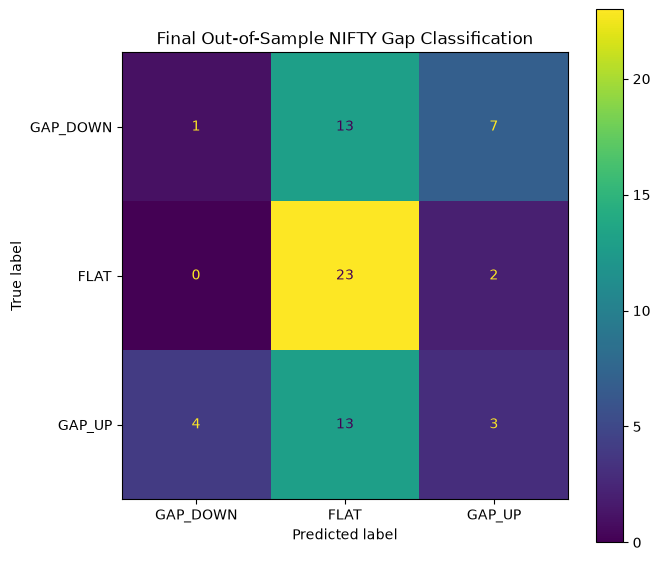

In [24]:

# ============================================================
# 21. FINAL CONFUSION MATRIX + REPORT
# ============================================================

labels = [
    "GAP_DOWN",
    "FLAT",
    "GAP_UP"
]

print(
    classification_report(
        final_test_results["Target_3Class"],
        final_test_results["Prediction"],
        labels=labels,
        zero_division=0
    )
)

cm = confusion_matrix(
    final_test_results["Target_3Class"],
    final_test_results["Prediction"],
    labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax)

ax.set_title(
    "Final Out-of-Sample NIFTY Gap Classification"
)

plt.tight_layout()
plt.show()



# 22. Baseline comparison

Always compare the model against simple alternatives.

The first baseline predicts the most common class in the final training sample every day.

If our sophisticated model cannot beat this baseline, the additional complexity is not justified.


In [25]:

# ============================================================
# 22. BASELINE
# ============================================================

baseline_class = (
    final_train["Target_3Class"]
    .value_counts()
    .idxmax()
)

baseline_prediction = np.repeat(
    baseline_class,
    len(final_test)
)

baseline_accuracy = accuracy_score(
    final_test["Target_3Class"],
    baseline_prediction
)

baseline_balanced = balanced_accuracy_score(
    final_test["Target_3Class"],
    baseline_prediction
)

print("Baseline class:", baseline_class)
print(f"Baseline accuracy: {baseline_accuracy:.2%}")
print(f"Model accuracy:    {final_metrics['Accuracy']:.2%}")

print(
    f"\nBaseline balanced accuracy: "
    f"{baseline_balanced:.2%}"
)

print(
    f"Model balanced accuracy:    "
    f"{final_metrics['Balanced_Accuracy']:.2%}"
)


Baseline class: GAP_UP
Baseline accuracy: 30.30%
Model accuracy:    40.91%

Baseline balanced accuracy: 33.33%
Model balanced accuracy:    37.25%



# 23. Test sensitivity to the FLAT threshold

The ±0.15% threshold is not a law of nature.

A particularly useful robustness check is to repeat the research using:

- ±0.10%
- ±0.15%
- ±0.20%
- ±0.25%
- ±0.30%

Changing the threshold changes both the economics of the target and class balance.

Do **not** choose the threshold by maximizing the final test performance. Use historical development data and then confirm once on the untouched test period.


In [26]:

# ============================================================
# 23. THRESHOLD SENSITIVITY — TARGET DISTRIBUTION
# ============================================================

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30]

threshold_summary = []

for threshold in thresholds:

    temp_target = np.select(
        [
            model_df["Gap_Pct"] > threshold,
            model_df["Gap_Pct"] < -threshold
        ],
        [
            "GAP_UP",
            "GAP_DOWN"
        ],
        default="FLAT"
    )

    counts = pd.Series(temp_target).value_counts()

    threshold_summary.append({
        "Threshold_%": threshold,
        "GAP_DOWN_%": (
            counts.get("GAP_DOWN", 0) /
            len(temp_target) * 100
        ),
        "FLAT_%": (
            counts.get("FLAT", 0) /
            len(temp_target) * 100
        ),
        "GAP_UP_%": (
            counts.get("GAP_UP", 0) /
            len(temp_target) * 100
        )
    })

threshold_summary_df = pd.DataFrame(
    threshold_summary
)

display(
    threshold_summary_df.round(2)
)


,Threshold_%,GAP_DOWN_%,FLAT_%,GAP_UP_%
0,0.10,24.96,19.64,55.41
1,0.15,21.88,28.93,49.20
2,0.20,18.96,37.80,43.24
3,0.25,16.60,45.78,37.63
4,0.30,14.40,54.01,31.59



# 24. Probability-based next-day prediction

The final model produces probabilities where supported by the estimator.

For the two-stage architecture, the exact probability of each final class requires multiplying the stage probabilities:

\[
P(UP)=P(GAP)	imes P(UP|GAP)
\]

\[
P(DOWN)=P(GAP)	imes P(DOWN|GAP)
\]

\[
P(FLAT)=P(FLAT)
\]

This gives a more useful output than simply reporting the predicted class.


In [27]:

# ============================================================
# 24. FINAL NEXT-DAY PREDICTION
# ============================================================

latest = model_df.iloc[[-1]].copy()

latest_X = latest[ALL_FEATURES]

print("Latest available date:", latest.index[-1].date())

if best_architecture == "Direct 3-Class":

    probabilities = final_model.predict_proba(
        latest_X
    )[0]

    class_order = list(final_model.classes_)

    probability_table = pd.DataFrame({
        "Class": class_order,
        "Probability": probabilities
    })

    prediction = final_model.predict(
        latest_X
    )[0]

else:

    # Stage 1 probabilities
    p1 = stage1_final.predict_proba(
        latest_X
    )[0]

    stage1_classes = list(
        stage1_final.classes_
    )

    p1_dict = dict(
        zip(stage1_classes, p1)
    )

    p_gap = p1_dict.get(1, 0.0)
    p_flat = p1_dict.get(0, 0.0)

    # Stage 2 probabilities
    p2 = stage2_final.predict_proba(
        latest_X
    )[0]

    stage2_classes = list(
        stage2_final.classes_
    )

    p2_dict = dict(
        zip(stage2_classes, p2)
    )

    p_up_given_gap = p2_dict.get(
        "GAP_UP",
        0.0
    )

    p_down_given_gap = p2_dict.get(
        "GAP_DOWN",
        0.0
    )

    p_up = p_gap * p_up_given_gap
    p_down = p_gap * p_down_given_gap

    probability_table = pd.DataFrame({
        "Class": [
            "GAP_DOWN",
            "FLAT",
            "GAP_UP"
        ],
        "Probability": [
            p_down,
            p_flat,
            p_up
        ]
    })

    prediction = probability_table.loc[
        probability_table["Probability"].idxmax(),
        "Class"
    ]

print("\nNEXT-DAY PREDICTION")
print("===================")
print("Predicted class:", prediction)

display(
    probability_table.sort_values(
        "Probability",
        ascending=False
    )
)


Latest available date: 2026-09-30

NEXT-DAY PREDICTION
Predicted class: FLAT


,Class,Probability
1,FLAT,0.656079
2,GAP_UP,0.265788
0,GAP_DOWN,0.078133



# 25. Save research outputs

The notebook saves:

1. The complete feature/target dataset.
2. Final out-of-sample predictions.
3. Model-selection results.
4. Threshold-sensitivity results.

These files can be used for further analysis in Excel/Python.


In [28]:

# ============================================================
# 25. SAVE OUTPUTS
# ============================================================

model_df.to_csv(
    "india_vix_nifty_gap_full_dataset.csv"
)

final_test_results.to_csv(
    "india_vix_nifty_final_test_predictions.csv"
)

comparison.to_csv(
    "india_vix_nifty_model_selection_results.csv",
    index=False
)

threshold_summary_df.to_csv(
    "india_vix_nifty_threshold_sensitivity.csv",
    index=False
)

print("Saved:")
print("1. india_vix_nifty_gap_full_dataset.csv")
print("2. india_vix_nifty_final_test_predictions.csv")
print("3. india_vix_nifty_model_selection_results.csv")
print("4. india_vix_nifty_threshold_sensitivity.csv")


Saved:
1. india_vix_nifty_gap_full_dataset.csv
2. india_vix_nifty_final_test_predictions.csv
3. india_vix_nifty_model_selection_results.csv
4. india_vix_nifty_threshold_sensitivity.csv



# 26. How to interpret the result

The most important output is **not simply accuracy**.

Look at:

### 1. Balanced accuracy
Does the model recognize all three classes?

### 2. Macro F1
Does the model perform reasonably across GAP_DOWN, FLAT and GAP_UP?

### 3. Confusion matrix
Is the model actually identifying directional gaps or simply predicting FLAT?

### 4. Performance by year
Does the model work across multiple market regimes?

### 5. Training-window comparison
Does 6M, 1Y, 2Y, 3Y or 5Y perform best during historical walk-forward testing?

### 6. Final untouched test
This is the most important out-of-sample number.

---

## Important research warning

Do not repeatedly change:

- the threshold,
- features,
- model,
- training window,
- recency half-life,

based on the final test period.

If you repeatedly optimize against the final test period, it stops being a true out-of-sample test.

A better research workflow is:

**Historical data → walk-forward model selection → freeze model → untouched final test → paper trading → live validation**

Only after that should the strategy be considered for actual trading.
